# 2. Множественная линейная регрессия

Как правило, при прогнозировании значения некой величины нам нужно учитывать не один, а много факторов так или иначе влияющих на нее.

В этой части лабораторной работы Вы решите задачу предсказания цены на дом при известных значениях его площади (в фут2) и числе спален.

Исходные данные - в файле ex1data2.txt

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data/ex1data2.txt', names=['size', 'bedrooms', 'price'])
data.head()

,size,bedrooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [2]:
data.describe()

,size,bedrooms,price
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


In [3]:
data[['size', 'bedrooms', 'price']] = data[['size', 'bedrooms', 'price']].apply(lambda x: (x - x.mean()) / x.std())
data.head()

,size,bedrooms,price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


In [4]:
data.describe()

,size,bedrooms,price
count,4.700000e+01,4.700000e+01,4.700000e+01
mean,3.779483e-17,2.746030e-16,-9.684924e-17
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.445423e+00,-2.851859e+00,-1.363666e+00
25%,-7.155897e-01,-2.236752e-01,-7.238702e-01
50%,-1.417900e-01,-2.236752e-01,-3.239979e-01
75%,3.376348e-01,1.090417e+00,3.521863e-01
max,3.117292e+00,2.404508e+00,2.874981e+00


In [5]:
# noinspection PyShadowingNames
def computeCost(X: np.matrix, y: np.matrix, theta: np.matrix) -> float:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    j = X @ theta - y
    return (j.T @ j).item() / (2 * len(y))

In [6]:
from typing import Tuple, List


# noinspection PyShadowingNames
def gradientDescent(X: np.matrix, y: np.matrix, theta: np.matrix, alpha: float, iters: int) -> Tuple[
    np.matrix, List[float]]:
    iters_history: List[float] = list()
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    for i in range(iters):
        theta = theta - (alpha / len(y)) * X.T @ (X @ theta - y)
        iters_history.append(computeCost(X=X, y=y, theta=theta))
    return theta, iters_history

In [7]:
# noinspection PyTypeChecker, PyShadowingNames
def predict(X: np.matrix, theta: np.matrix) -> np.matrix:
    return X @ theta

Найдите значение целевой функции при $\theta_0 = \theta_1 = \theta_2 = 0$.

Проверьте, что оно равно $0,489$.

In [8]:
X = np.column_stack([np.ones(len(data)), data.iloc[:, :-1]])
y = data['price'].values
theta = np.zeros((3, 1))

result: float = computeCost(X=X, y=y, theta=theta)
print(f'result = {result}')

result = 0.4893617021276595


Найдите значение параметров  $\theta_0, \theta_1, \theta_2$ после `iters = 1000` итераций алгоритма `gradientDescent(X, y, theta, alpha, iters)` с шагом `alpha = 0.05`.

Вычислите значение целевой функции для новых значений параметров. Убедитесь, что оно равно 0.13.

In [9]:
alpha: float = 0.05
iters: int = 1000
new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters)
print(f'new_theta =\n {new_theta}')
print(f'J(new_theta) = {iters_history[-1]}')

new_theta =
 [[-1.10669937e-16]
 [ 8.84765988e-01]
 [-5.31788195e-02]]
J(new_theta) = 0.130686480539042


Постройте график изменения функции потерь в процессе обучения.

Можете ли Вы добиться меньшего, чем 0.13 значения этой функции? Можно ли получить 0?

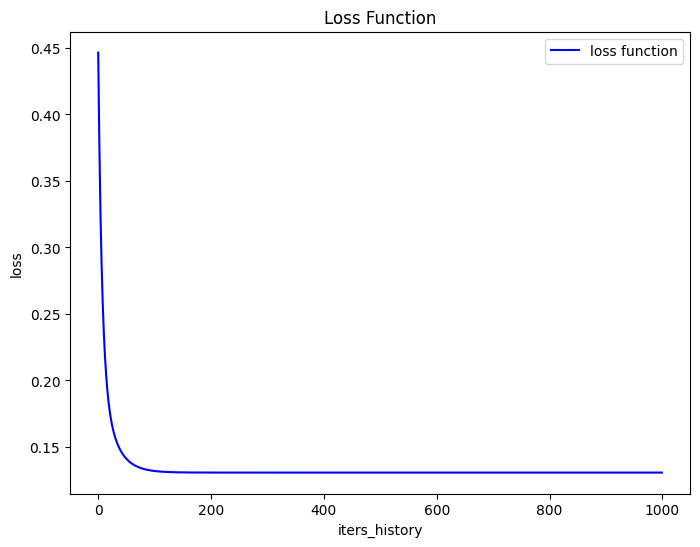

In [10]:
# Визуализация функции потерь
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, iters), iters_history, label='loss function', color='blue')
plt.title('Loss Function')
plt.xlabel('iters_history')
plt.ylabel('loss')
plt.legend()
plt.show()

Text(0, 0.5, 'Predicted')

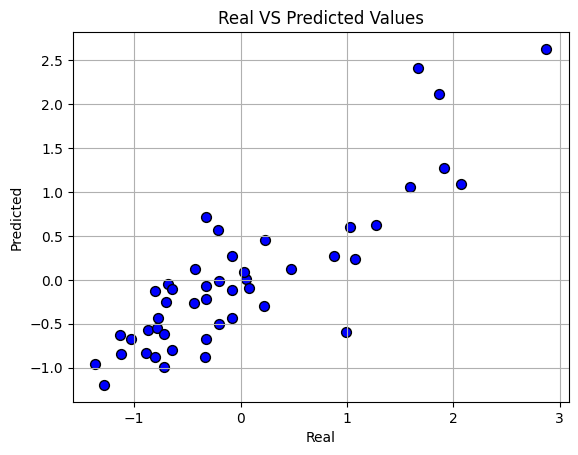

In [11]:
# Визуализация результата работы многомерной линейной регрессии: scatter plot
plt.scatter(y, predict(X=X, theta=new_theta), color='blue', marker='o', edgecolor='black', s=50)
plt.grid(True)
plt.title("Real VS Predicted Values")
plt.xlabel('Real')
plt.ylabel('Predicted')

In [12]:
samples: List[Tuple[float, int]] = [
    (0.01, 1000),
    (0.05, 100),
    (0.05, 3000),
    (0.05, 10000),
    (0.9, 1000),
    (0.001, 1000),
]

for (alpha, iters) in samples:
    new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters)
    print(f'new_theta =\n {new_theta}')
    print(f'J(new_theta) = {iters_history[-1]}', end='\n\n')

# Как будто нельзя сделать результат функции потерь < 0.13
# Значение меняется минимум на уровне десятитысячных, далее происходит резкое увеличение значения при большом альфа, а при меньшем - значение не изменяется.

new_theta =
 [[-1.10778357e-16]
 [ 8.78503652e-01]
 [-4.69166570e-02]]
J(new_theta) = 0.13070336960771892

new_theta =
 [[-1.17690146e-16]
 [ 8.31438738e-01]
 [-1.47491164e-04]]
J(new_theta) = 0.13190446569951927

new_theta =
 [[-1.12160715e-16]
 [ 8.84765988e-01]
 [-5.31788197e-02]]
J(new_theta) = 0.130686480539042

new_theta =
 [[-1.11618614e-16]
 [ 8.84765988e-01]
 [-5.31788197e-02]]
J(new_theta) = 0.130686480539042

new_theta =
 [[-8.89045781e-17]
 [ 8.84765988e-01]
 [-5.31788197e-02]]
J(new_theta) = 0.13068648053904197

new_theta =
 [[-8.35310011e-17]
 [ 4.89708382e-01]
 [ 1.61439744e-01]]
J(new_theta) = 0.18313435994592286



# Считаем сами

In [13]:
size_mean, size_std = data['size'].mean(), data['size'].std()
bedrooms_mean, bedrooms_std = data['bedrooms'].mean(), data['bedrooms'].std()
price_mean, price_std = data['price'].mean(), data['price'].std()
size: float = 3000
bedrooms: float = 4

predict_res = predict(np.array([[1, (size - size_mean) / size_std, (bedrooms - bedrooms_mean) / bedrooms_std]]), new_theta)
print(f'Для площади 3000 и числа комнат 4: {predict_res * price_std + price_mean}')

Для площади 3000 и числа комнат 4: [[1469.7709063]]
